# Training Neural Networks

## Part 1: Keras

### Goals:
- Intro: train a neural network with `tensorflow` and the Keras layers

### 1. Dataset:
- Digits: 10 class handwritten digits
- http://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html#sklearn.datasets.load_digits

In [ ]:
# Install Tensorflow
!pip install tensorflow



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers
digits = load_digits()

In [ ]:
digits.images.shape

(1797, 8, 8)

In [ ]:
digits.data.shape

(1797, 64)

In [ ]:
digits.target.shape

(1797,)

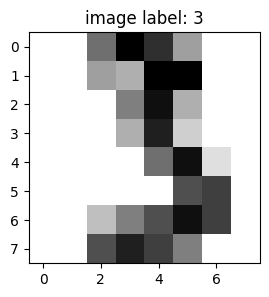

In [ ]:
sample_index = 45
plt.figure(figsize=(3, 3))
plt.imshow(digits.images[sample_index], cmap=plt.cm.gray_r,
           interpolation='nearest')
plt.title("image label: %d" % digits.target[sample_index]);

## a. Train / Test Split

Let's keep some held-out data to be able to measure the generalization performance of our model.

In [ ]:
data = np.asarray(digits.data, dtype='float32')
target = np.asarray(digits.target, dtype='int32')

# Split du dataset en train et test (15% pour le test)
X_train, X_test, y_train, y_test = train_test_split(
    data,
    target,
    test_size=0.15,
    random_state=42
)

In [ ]:
#Show the shape of the data. Xtrain, ytrain,...
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1527, 64)
y_train shape: (1527,)
X_test shape: (270, 64)
y_test shape: (270,)


## b. Preprocessing of the Input Data


Make sure that all input variables are approximately on the same scale via input normalization:

In [ ]:
scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Mean (train):", X_train.mean())
print("Std (train):", X_train.std())

Mean (train): -2.9665703e-09
Std (train): 0.97628117


Let's display the one of the transformed sample (after feature standardization):

Text(0.5, 1.0, 'Échantillon transformé\n(standardisation)')

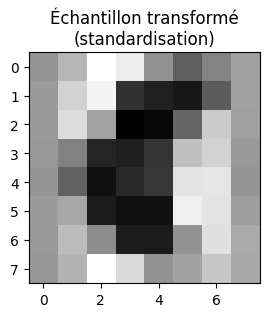

In [ ]:
indice_echantillon = 45
plt.figure(figsize=(3, 3))
plt.imshow(X_train[indice_echantillon].reshape(8, 8),
           cmap=plt.cm.gray_r, interpolation='nearest')
plt.title("Échantillon transformé\n(standardisation)")

The scaler objects makes it possible to recover the original sample:

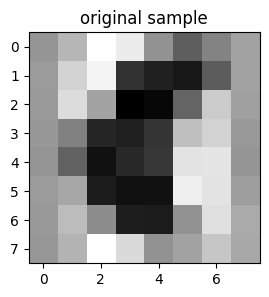

In [ ]:
import matplotlib.pyplot as plt

sample_index = 45

original_sample = scaler.inverse_transform(X_train[sample_index].reshape(1, -1))
original_sample = original_sample.reshape(8, 8)

plt.figure(figsize=(3, 3))
plt.imshow(original_sample, cmap=plt.cm.gray_r, interpolation='nearest')
plt.title("original sample")
plt.show()


In [ ]:
print(X_train.shape, y_train.shape)

(1527, 64) (1527, 10)


In [ ]:
print(X_test.shape, y_test.shape)

(270, 64) (270, 10)


## c. Preprocessing of the Target Data


To train a first neural network we also need to turn the target variable into a vector "one-hot-encoding" representation. Here are the labels of the first samples in the training set encoded as integers:

In [ ]:
y_train[:3]

array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]])

Keras provides a utility function to convert integer-encoded categorical variables as one-hot encoded values:

In [ ]:
y_train = to_categorical(y_train)
y_test  = to_categorical(y_test)

print("Premières 3 étiquettes encodées en one-hot :")
print(y_train[:3])

Premières 3 étiquettes encodées en one-hot :
[[[1. 0.]
  [0. 1.]
  [1. 0.]
  [1. 0.]
  [1. 0.]
  [1. 0.]
  [1. 0.]
  [1. 0.]
  [1. 0.]
  [1. 0.]]

 [[1. 0.]
  [1. 0.]
  [1. 0.]
  [1. 0.]
  [1. 0.]
  [0. 1.]
  [1. 0.]
  [1. 0.]
  [1. 0.]
  [1. 0.]]

 [[1. 0.]
  [1. 0.]
  [1. 0.]
  [0. 1.]
  [1. 0.]
  [1. 0.]
  [1. 0.]
  [1. 0.]
  [1. 0.]
  [1. 0.]]]


## 2. Feed Forward Neural Networks with Keras

Objectives of this section:

- Build and train a first feedforward network using `Keras`
    - https://www.tensorflow.org/guide/keras/overview
    - https://www.tensorflow.org/guide/keras/sequential_model
- Experiment with different optimizers, activations, size of layers, initializations

### a. First Keras Model

We can now build an train a our first feed forward neural network using the high level API from keras:

- first, define the model by stacking layers with the right dimensions
- then, define a loss function and plug the SGD optimizer
- then, feed the model the training data for fixed number of epochs

In [ ]:
# -------------------------------
# Import des librairies
# -------------------------------
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical

# -------------------------------
# 1️⃣ Préparer les données
# -------------------------------
# Supposons que X_train, X_test, y_train, y_test existent déjà

# Déterminer le nombre de classes
n_classes = len(np.unique(y_train))

# Transformation des labels en one-hot (2D)
y_train_oh = to_categorical(y_train.reshape(-1), num_classes=n_classes)
y_test_oh  = to_categorical(y_test.reshape(-1), num_classes=n_classes)

print("Forme de y_train_oh :", y_train_oh.shape)
print("Forme de y_test_oh  :", y_test_oh.shape)

# -------------------------------
# 2️⃣ Définir le modèle Keras
# -------------------------------
input_dim = X_train.shape[1]
hidden_dim = 100
output_dim = n_classes

modele = Sequential([
    Input(shape=(input_dim,)),
    Dense(hidden_dim, activation='tanh'),   # Couche cachée
    Dense(output_dim, activation='softmax') # Couche de sortie
])


modele.compile(
    loss='categorical_crossentropy',
    optimizer=SGD(learning_rate=0.1),
    metrics=['accuracy']
)

historique = modele.fit(
    X_train,
    y_train_oh,
    validation_split=0.2,
    epochs=15,
    verbose=2
)


train_loss, train_acc = modele.evaluate(X_train, y_train_oh, verbose=0)
test_loss, test_acc   = modele.evaluate(X_test, y_test_oh, verbose=0)

print(f"Précision sur le jeu d'entraînement : {train_acc:.3f}")
print(f"Précision sur le jeu de test        : {test_acc:.3f}")

if train_acc > 0.95 and test_acc < 0.90:
    print("Le modèle semble surapprendre : précision élevée sur le train mais plus faible sur le test.")
elif train_acc < 0.90 and test_acc < 0.90:
    print("Le modèle semble sous-apprendre : précision faible sur le train et le test.")
else:
    print("Le modèle semble bien ajusté : précision similaire sur le train et le test.")

Forme de y_train_oh : (30540, 2)
Forme de y_test_oh  : (5400, 2)
Epoch 1/15
39/39 - 2s - 39ms/step - accuracy: 0.5291 - loss: 0.7589 - val_accuracy: 0.5327 - val_loss: 0.7944
Epoch 2/15
39/39 - 1s - 19ms/step - accuracy: 0.5094 - loss: 0.7124 - val_accuracy: 0.4771 - val_loss: 0.8589
Epoch 3/15
39/39 - 1s - 19ms/step - accuracy: 0.5651 - loss: 0.7033 - val_accuracy: 0.4967 - val_loss: 0.8200
Epoch 4/15
39/39 - 0s - 11ms/step - accuracy: 0.5815 - loss: 0.6834 - val_accuracy: 0.5000 - val_loss: 0.7446
Epoch 5/15
39/39 - 1s - 14ms/step - accuracy: 0.5749 - loss: 0.6777 - val_accuracy: 0.4542 - val_loss: 0.7911
Epoch 6/15
39/39 - 0s - 8ms/step - accuracy: 0.5848 - loss: 0.6737 - val_accuracy: 0.5229 - val_loss: 0.7440
Epoch 7/15
39/39 - 0s - 7ms/step - accuracy: 0.5799 - loss: 0.6644 - val_accuracy: 0.4967 - val_loss: 0.8112
Epoch 8/15
39/39 - 0s - 6ms/step - accuracy: 0.5954 - loss: 0.6625 - val_accuracy: 0.4837 - val_loss: 0.7468
Epoch 9/15
39/39 - 0s - 4ms/step - accuracy: 0.6069 - loss

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 1527
'y' sizes: 30540


In [ ]:
# Show the model summery.
model.summary()


### b. Visualizing the Convergence

Let's wrap the keras history info into a pandas dataframe for easier plotting:

In [ ]:
import pandas as pd

history_df = pd.DataFrame(history.history)
history_df["epoch"] = history.epoch

In [ ]:

history_df = pd.DataFrame(history.history)
history_df["epoch"] = history_df.index + 1  # add epoch column
fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True, figsize=(12, 6))
history_df.plot(x="epoch", y=["loss", "val_loss"], ax=ax0, title="Loss")
history_df.plot(x="epoch", y=["accuracy", "val_accuracy"], ax=ax1, title="Accuracy")
plt.show()


### c. Impact of the Optimizer

- Try to decrease the learning rate value by 10x or 100x. What do you observe?

- Try to increase the learning rate value to make the optimization diverge.

- Configure the SGD optimizer to enable a Nesterov momentum of 0.9
  
**Notes**:

The keras API documentation is available at:

https://www.tensorflow.org/api_docs/python/tf/keras

It is also possible to learn more about the parameters of a class by using the question mark: type and evaluate:

```python
optimizers.SGD?
```

in a jupyter notebook cell.

It is also possible to type the beginning of a function call / constructor and type "shift-tab" after the opening paren:

```python
optimizers.SGD(<shiff-tab>
```

In [ ]:
optimizers.SGD?

In [ ]:
learning_rates = [0.1, 0.01, 0.001]
histories = {}

for lr in learning_rates:
    print(f"\nTraining model with learning rate = {lr}")

    model = Sequential()
    model.add(Dense(hidden_dim, activation='tanh', input_dim=input_dim))
    model.add(Dense(output_dim, activation='softmax'))

    model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizers.SGD(learning_rate=lr),
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=15,
        verbose=1
    )

    histories[lr] = history


- Replace the SGD optimizer by the Adam optimizer from keras and run it
  with the default parameters.

  Hint: use `optimizers.<TAB>` to tab-complete the list of implemented optimizers in Keras.

- Add another hidden layer and use the "Rectified Linear Unit" for each
  hidden layer. Can you still train the model with Adam with its default global
  learning rate?

In [ ]:
# Your code and your Analysis here.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers

model_adam = Sequential()
model_adam.add(Dense(hidden_dim, activation='relu', input_dim=input_dim))
model_adam.add(Dense(hidden_dim, activation='relu'))
model_adam.add(Dense(output_dim, activation='softmax'))

# Compile the model using Adam with default parameters
model_adam.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(),
    metrics=['accuracy']
)

# Train the model
history_adam = model_adam.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=15,
    verbose=1
)

### d. Forward Pass and Generalization

- Compute predictions on test set using `model.predict(...)`
- Compute average accuracy of the model on the test set: the fraction of test samples for which the model makes a prediction that matches the true label.

In [ ]:
# Your code and your Analysis


# Forward pass: prédictions sur le jeu de test
y_pred_prob = model_adam.predict(X_test)

# Conversion des probabilités en labels prédits
y_pred = np.argmax(y_pred_proba, axis=1)

# Conversion des labels one-hot en labels entiers
y_true = np.argmax(y_test, axis=1)

# Calcul de l'accuracy sur le jeu de test
test_accuracy = np.mean(y_pred == y_true)

print("Test accuracy:", test_accuracy)


### e. numpy arrays vs tensorflow tensors

In the previous exercises we used `model.predict(...)` that returns a numpy array:

In [ ]:
import numpy as np

y_pred_prob = model.predict(X_test)
predicted_labels_numpy = np.argmax(y_pred_prob, axis=1)
predicted_labels_numpy


In [ ]:
type(predicted_labels_numpy), predicted_labels_numpy.shape

Alternatively one can directly call the model on the data to get the laster layer (softmax) outputs directly as a tensorflow Tensor:

In [ ]:
predictions_tf = model(X_test)
predictions_tf[:5]

In [ ]:
type(predictions_tf), predictions_tf.shape

We can use the tensorflow API to check that for each row, the probabilities sum to 1:

In [ ]:
import tensorflow as tf

tf.reduce_sum(predictions_tf, axis=1)[:5]

We can also extract the label with the highest probability using the tensorflow API:

In [ ]:
predicted_labels_tf = tf.argmax(predictions_tf, axis=1)
predicted_labels_tf[:5]

We can compare those labels to the expected labels to compute the accuracy with the Tensorflow API. Note however that we need an explicit cast from boolean to floating point values to be able to compute the mean accuracy when using the tensorflow tensors:

In [ ]:
accuracy_tf = tf.reduce_mean(tf.cast(predicted_labels_tf == y_test, tf.float64))
accuracy_tf

Also note that it is possible to convert tensors to numpy array if one prefer to use numpy:

In [ ]:
#for converting tensor to numpy array
array = accuracy_tf.numpy()
array

In [ ]:
predicted_labels_tf[:5]

In [ ]:
predicted_labels_tf.numpy()[:5]

## 3. Impact of Initialization

Let us now study the impact of a bad initialization when training
a deep feed forward network.

By default Keras dense layers use the "Glorot Uniform" initialization
strategy to initialize the weight matrices:

- each weight coefficient is randomly sampled from [-scale, scale]
- scale is proportional to $\frac{1}{\sqrt{n_{in} + n_{out}}}$

This strategy is known to work well to initialize deep neural networks
with "tanh" or "relu" activation functions and then trained with
standard SGD.

To assess the impact of initialization let us plug an alternative init
scheme into a 2 hidden layers networks with "tanh" activations.
For the sake of the example let's use normal distributed weights
with a manually adjustable scale (standard deviation) and see the
impact the scale value:

In [ ]:
from tensorflow.keras import initializers

normal_init = initializers.TruncatedNormal(stddev=0.01)


model = Sequential()
model.add(Dense(hidden_dim, input_dim=input_dim, activation="tanh",
                kernel_initializer=normal_init))
model.add(Dense(hidden_dim, activation="tanh",
                kernel_initializer=normal_init))
model.add(Dense(output_dim, activation="softmax",
                kernel_initializer=normal_init))

model.compile(optimizer=optimizers.SGD(learning_rate=0.1),
              loss='categorical_crossentropy', metrics=['accuracy'])



In [ ]:
model.layers

Let's have a look at the parameters of the first layer after initialization but before any training has happened:

In [ ]:
model.layers[0].weights

In [ ]:
w = model.layers[0].weights[0]
w

In [ ]:
b = model.layers[0].weights[1]
b

In [ ]:
history = model.fit(X_train, y_train, epochs=15, batch_size=32)

plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label="Truncated Normal init")
plt.legend();

Once the model has been fit, the weights have been updated and notably the biases are no longer 0:

In [ ]:
model.layers[0].weights

#### Questions:

- Try the following initialization schemes and see whether
  the SGD algorithm can successfully train the network or
  not:
  
  - a very small e.g. `stddev=1e-3`
  - a larger scale e.g. `stddev=1` or `10`
  - initialize all weights to 0 (constant initialization)
  
- What do you observe? Can you find an explanation for those
  outcomes?

- Are more advanced solvers such as SGD with momentum or Adam able
  to deal better with such bad initializations? test it and explain

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import initializers, optimizers
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

# Chargement du dataset Digits
digits = load_digits()
X = digits.data
y = digits.target

# Normalisation
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encoding
y_cat = to_categorical(y, num_classes=10)

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.15, random_state=42
)

input_dim = X_train.shape[1]
hidden_dim = 100
output_dim = 10

# Fonction de création et entraînement du modèle
def train_model(init_type, optimizer_type, epochs=50):

    # Initialisation des poids
    if init_type == "small":
        initializer = initializers.RandomNormal(stddev=1e-3)
    elif init_type == "large":
        initializer = initializers.RandomNormal(stddev=1.0)
    elif init_type == "very_large":
        initializer = initializers.RandomNormal(stddev=10.0)
    elif init_type == "zeros":
        initializer = initializers.Zeros()
    else:
        raise ValueError("Type d'initialisation inconnu")

    # Optimiseur
    if optimizer_type == "sgd":
        optimizer = optimizers.SGD(learning_rate=0.01)
    elif optimizer_type == "momentum":
        optimizer = optimizers.SGD(learning_rate=0.01, momentum=0.9)
    elif optimizer_type == "adam":
        optimizer = optimizers.Adam(learning_rate=0.001)
    else:
        raise ValueError("Optimiseur inconnu")

    # Modèle
    model = Sequential([
        Dense(hidden_dim, activation='relu',
              kernel_initializer=initializer,
              input_shape=(input_dim,)),
        Dense(output_dim, activation='softmax',
              kernel_initializer=initializer)
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=32,
        verbose=0
    )

    return model, history

In [ ]:
configs = [
    ("small", "sgd"),
    ("large", "sgd"),
    ("very_large", "sgd"),
    ("zeros", "sgd"),
    ("zeros", "momentum"),
    ("zeros", "adam"),
]

plt.figure(figsize=(10,6))

for init_type, opt in configs:
    _, hist = train_model(init_type, opt)
    plt.plot(hist.history['val_accuracy'],
             label=f"{init_type} + {opt}")

plt.xlabel("Epochs")
plt.ylabel("Validation accuracy")
plt.title("Impact de l'initialisation et de l'optimiseur")
plt.legend()
plt.grid(True)
plt.show()

## 4. Callback
TensorFlow Callbacks are powerful tools that allow you to monitor and modify the behavior of a model during its training, evaluation, or inference stages. They are particularly useful for tasks like early stopping, saving checkpoints, logging metrics, and dynamically adjusting hyperparameters.
              https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/Callback
              

a. Implement a call back for early stopping and train one of previous  model with 50 epochs.
What do you observe? What is the functionality of this call back?
https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import optimizers, initializers
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

# Chargement des données
digits = load_digits()
X = digits.data
y = digits.target

# Normalisation
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encoding
y_cat = to_categorical(y, num_classes=10)

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.15, random_state=42
)

# Modèle MLP
model = Sequential([
    Dense(100, activation='relu',
          kernel_initializer=initializers.RandomNormal(stddev=0.01),
          input_shape=(X_train.shape[1],)),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callback Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',      # métrique surveillée
    patience=5,              # nombre d'epochs sans amélioration tolérées
    restore_best_weights=True
)

# Entraînement avec 50 epochs max
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Early Stopping effect")
plt.legend()
plt.grid(True)
plt.show()

b. Implement a call back for ModelCheckpoint and train the model with 50 epochs. What do you observe? What is the functionality of this call back?https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint

In [ ]:
#Your code and Analysis here.
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import optimizers, initializers
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import os

# Reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

# Chargement des données
digits = load_digits()
X = digits.data
y = digits.target

# Normalisation
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encoding
y_cat = to_categorical(y, num_classes=10)

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.15, random_state=42
)

# Modèle MLP
model = Sequential([
    Dense(100, activation='relu',
          kernel_initializer=initializers.RandomNormal(stddev=0.01),
          input_shape=(X_train.shape[1],)),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Dossier de sauvegarde
checkpoint_path = "best_model.keras"

# Callback ModelCheckpoint
model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# Entraînement avec 50 epochs
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[model_checkpoint],
    verbose=1
)


c. Implement a call back for TensorBoard and train the model. What do you observe? https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/TensorBoard

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras import optimizers, initializers
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
import datetime

# Reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

# Chargement des données
digits = load_digits()
X = digits.data
y = digits.target

# Normalisation
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encoding
y_cat = to_categorical(y, num_classes=10)

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.15, random_state=42
)

# Modèle MLP
model = Sequential([
    Dense(100, activation='relu',
          kernel_initializer=initializers.RandomNormal(stddev=0.01),
          input_shape=(X_train.shape[1],)),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Dossier de logs TensorBoard
log_dir = "logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,   # active les histogrammes des poids
    write_graph=True
)

# Entraînement
model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[tensorboard_callback],
    verbose=1
)




Execute the following code.

In [ ]:
%load_ext tensorboard
%tensorboard --logdir logs



What is functionality of tensorborad?

TensorBoard est un outil de visualisation de TensorFlow qui permet de suivre et analyser l’entraînement d’un modèle.

Il affiche l’évolution des métriques (loss, accuracy), la structure du réseau et la distribution des poids.
Il aide à détecter le sur-apprentissage, les problèmes de convergence et à mieux comprendre le comportement du modèle pendant l’entraînement.

## Part 2: Sckilearn

### Goals:
- Intro: train a neural network with `Sklearn` and MLPClassifier
- https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier
- We use the same strategy and previous dataset.

Use the previous dataset and standardScalar for preprocessing.
Implement MLPClassifier with 500 iteration and activation='relu'and train it.
Use model predection.
Print the confusion matrix.


In [ ]:
#Your code here.
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Chargement du dataset
digits = load_digits()
X = digits.data
y = digits.target

# Normalisation
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Modèle MLPClassifier
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

# Entraînement
mlp.fit(X_train, y_train)

# Prédictions
y_pred = mlp.predict(X_test)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Affichage
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - MLPClassifier")
plt.show()


At which iteration did the model stop?

In [ ]:

mlp.n_iter_



NameError: name 'mlp' is not defined

Can you explain the main differences between this model (scikit-learn MLP) and one built with Keras? Can we use this model for all neural network problems?

Le MLP de scikit-learn ne peut pas être utilisé pour tous les problèmes de réseaux de neurones. Il est idéal pour des tâches simples et rapides, tandis que Keras est préférable pour des modèles profonds, complexes ou industriels.